# Bài tập Buổi 7: Logistic Regression và KNN

**Họ và tên:** Tạ Tuấn Khải 
**MSSV:** 2452515

Bài làm gồm:

1. Titanic: Logistic Regression và so sánh với Linear Regression.
2. Dry Bean: Logistic Regression và KNN.

Phần Titanic dùng lại đúng cách chia dữ liệu và pipeline tiền xử lý của bài Buổi 5:

- Train, validation, test gần 70%, 15%, 15%.
- `random_state=42`.
- `stratify`.
- Bộ tiền xử lý chỉ `fit` trên tập train.

## 0. Chuẩn bị môi trường

Notebook cần các thư viện: `numpy`, `pandas`, `matplotlib`, `scikit-learn`.

In [1]:
pip install numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)
np.random.seed(RANDOM_STATE)

print("Sẵn sàng.")

Sẵn sàng.


# Bài 1: Titanic Dataset

## Task 1. Đọc dữ liệu

Chỉ giữ tám cột đã dùng trong bài Buổi 5:

`survived, pclass, sex, age, sibsp, parch, fare, embarked`.

In [3]:
LOCAL_CANDIDATES = [
    Path("titanic.csv"),
    Path("data/titanic.csv"),
    Path("../titanic.csv"),
    Path("../../week03/titanic.csv"),
    Path("../../week03/data/titanic.csv"),
]

titanic_raw = None
titanic_source = None

for candidate in LOCAL_CANDIDATES:
    if candidate.exists():
        titanic_raw = pd.read_csv(candidate)
        titanic_source = str(candidate.resolve())
        break

if titanic_raw is None:
    try:
        titanic_raw = sns.load_dataset("titanic")
        titanic_source = "seaborn.load_dataset('titanic')"
    except Exception:
        url = (
            "https://raw.githubusercontent.com/"
            "mwaskom/seaborn-data/master/titanic.csv"
        )
        titanic_raw = pd.read_csv(url)
        titanic_source = url

titanic_raw.columns = (
    titanic_raw.columns
    .str.strip()
    .str.lower()
)

keep_cols = [
    "survived", "pclass", "sex", "age",
    "sibsp", "parch", "fare", "embarked"
]
missing_cols = [
    column for column in keep_cols
    if column not in titanic_raw.columns
]

if missing_cols:
    raise ValueError(
        f"Dataset Titanic thiếu các cột: {missing_cols}"
    )

titanic = titanic_raw[keep_cols].copy()

print("Nguồn dữ liệu:", titanic_source)
print("Kích thước:", titanic.shape)
print("Missing values:")
display(titanic.isna().sum().to_frame("missing_count"))
display(titanic.head())

Nguồn dữ liệu: seaborn.load_dataset('titanic')
Kích thước: (891, 8)
Missing values:


,missing_count
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Task 2. Chia train, validation, test giống bài Buổi 5

Hai mô hình Titanic được huấn luyện trên đúng tập train gồm 623 mẫu. Tập test gồm 134 mẫu được giữ độc lập để so sánh.

In [4]:
X = titanic.drop(columns="survived")
y = titanic["survived"]

# Lần 1: tách 15% làm test
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Lần 2: tách 15% toàn bộ dữ liệu làm validation
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp,
    y_tmp,
    test_size=0.15 / 0.85,
    random_state=RANDOM_STATE,
    stratify=y_tmp,
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

for name, target in [
    ("Train", y_train),
    ("Validation", y_val),
    ("Test", y_test),
]:
    print(f"{name}: tỷ lệ sống sót = {target.mean():.4f}")

Train: (623, 7)
Validation: (134, 7)
Test: (134, 7)
Train: tỷ lệ sống sót = 0.3836
Validation: tỷ lệ sống sót = 0.3881
Test: tỷ lệ sống sót = 0.3806


## Task 3. Tiền xử lý giống bài Buổi 5

- Biến số: điền median, sau đó dùng `RobustScaler`.
- Biến phân loại: điền mode, sau đó One-Hot Encoding.
- `pclass`: giữ nguyên như biến thứ tự.
- `preprocess.fit()` chỉ chạy trên `X_train`.

In [5]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

pipe_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
    )),
])

preprocess = ColumnTransformer([
    ("num", pipe_num, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
], verbose_feature_names_out=False)

# Chỉ học thống kê từ tập train
preprocess.fit(X_train)

X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

feature_names = preprocess.get_feature_names_out().tolist()

print("Train sau xử lý:", X_train_t.shape)
print("Validation sau xử lý:", X_val_t.shape)
print("Test sau xử lý:", X_test_t.shape)
print("Số NaN trong train:", int(np.isnan(X_train_t).sum()))
print("Số NaN trong validation:", int(np.isnan(X_val_t).sum()))
print("Số NaN trong test:", int(np.isnan(X_test_t).sum()))
print("Tên đặc trưng:", feature_names)

Train sau xử lý: (623, 10)
Validation sau xử lý: (134, 10)
Test sau xử lý: (134, 10)
Số NaN trong train: 0
Số NaN trong validation: 0
Số NaN trong test: 0
Tên đặc trưng: ['age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'pclass']


## Task 4. Hàm đánh giá phân loại nhị phân

In [6]:
def evaluate_binary_model(model_name, y_true, y_pred):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "F1-score": f1_score(
            y_true, y_pred, zero_division=0
        ),
    }

    print(model_name)
    display(pd.DataFrame([metrics], index=[model_name]))

    print("\nClassification report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Không sống sót", "Sống sót"],
        zero_division=0,
    ))

    return metrics

## Task 5. Logistic Regression

In [7]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
)

logistic_model.fit(X_train_t, y_train)

logistic_val_pred = logistic_model.predict(X_val_t)
logistic_test_pred = logistic_model.predict(X_test_t)

print("Kết quả trên validation:")
_ = evaluate_binary_model(
    "Logistic Regression, validation",
    y_val,
    logistic_val_pred,
)

print("\nKết quả trên test:")
logistic_metrics = evaluate_binary_model(
    "Logistic Regression, test",
    y_test,
    logistic_test_pred,
)

Kết quả trên validation:
Logistic Regression, validation


,Accuracy,Precision,Recall,F1-score
"Logistic Regression, validation",0.8284,0.7544,0.8269,0.789



Classification report:
                precision    recall  f1-score   support

Không sống sót       0.88      0.83      0.86        82
      Sống sót       0.75      0.83      0.79        52

      accuracy                           0.83       134
     macro avg       0.82      0.83      0.82       134
  weighted avg       0.83      0.83      0.83       134


Kết quả trên test:
Logistic Regression, test


,Accuracy,Precision,Recall,F1-score
"Logistic Regression, test",0.7761,0.7442,0.6275,0.6809



Classification report:
                precision    recall  f1-score   support

Không sống sót       0.79      0.87      0.83        83
      Sống sót       0.74      0.63      0.68        51

      accuracy                           0.78       134
     macro avg       0.77      0.75      0.75       134
  weighted avg       0.77      0.78      0.77       134



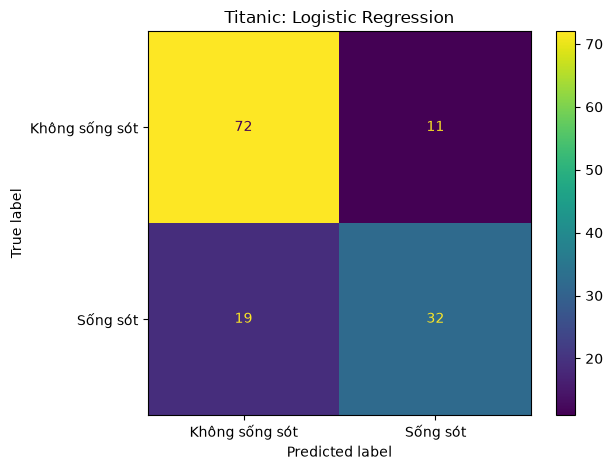

In [8]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_test_pred,
    display_labels=["Không sống sót", "Sống sót"],
)
plt.title("Titanic: Logistic Regression")
plt.tight_layout()
plt.show()

## Task 6. Linear Regression dùng ngưỡng 0,5

Linear Regression trả về số thực. Để so sánh trong bài toán phân loại:

- Giá trị dự đoán từ 0,5 trở lên được gán lớp 1.
- Giá trị dưới 0,5 được gán lớp 0.

In [9]:
linear_model = LinearRegression()
linear_model.fit(X_train_t, y_train)

linear_test_score = linear_model.predict(X_test_t)
linear_test_pred = (linear_test_score >= 0.5).astype(int)

linear_metrics = evaluate_binary_model(
    "Linear Regression + threshold 0.5",
    y_test,
    linear_test_pred,
)

print("\nKhoảng giá trị dự đoán của Linear Regression:")
print("Min:", round(float(linear_test_score.min()), 4))
print("Max:", round(float(linear_test_score.max()), 4))

Linear Regression + threshold 0.5


,Accuracy,Precision,Recall,F1-score
Linear Regression + threshold 0.5,0.7612,0.7021,0.6471,0.6735



Classification report:
                precision    recall  f1-score   support

Không sống sót       0.79      0.83      0.81        83
      Sống sót       0.70      0.65      0.67        51

      accuracy                           0.76       134
     macro avg       0.75      0.74      0.74       134
  weighted avg       0.76      0.76      0.76       134


Khoảng giá trị dự đoán của Linear Regression:
Min: -0.2237
Max: 1.0574


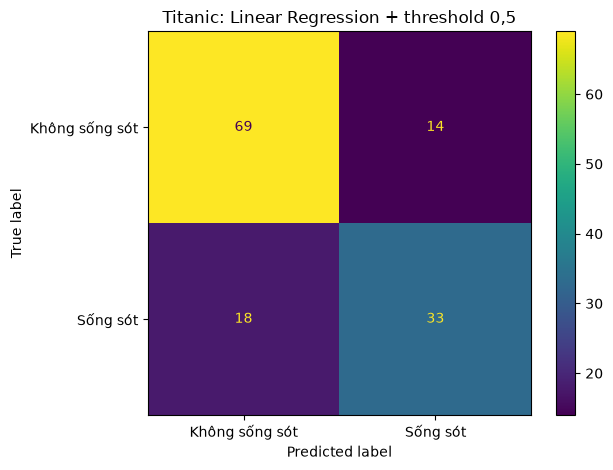

In [10]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    linear_test_pred,
    display_labels=["Không sống sót", "Sống sót"],
)
plt.title("Titanic: Linear Regression + threshold 0,5")
plt.tight_layout()
plt.show()

## Task 7. So sánh Logistic Regression và Linear Regression

In [11]:
titanic_comparison = pd.DataFrame({
    "Logistic Regression": logistic_metrics,
    "Linear Regression + threshold 0.5": linear_metrics,
}).T

display(titanic_comparison.round(4))

print("Confusion Matrix, Logistic Regression:")
print(confusion_matrix(y_test, logistic_test_pred))

print("\nConfusion Matrix, Linear Regression:")
print(confusion_matrix(y_test, linear_test_pred))

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.7761,0.7442,0.6275,0.6809
Linear Regression + threshold 0.5,0.7612,0.7021,0.6471,0.6735


Confusion Matrix, Logistic Regression:
[[72 11]
 [19 32]]

Confusion Matrix, Linear Regression:
[[69 14]
 [18 33]]


In [12]:
log_cm = confusion_matrix(y_test, logistic_test_pred)
lin_cm = confusion_matrix(y_test, linear_test_pred)

log_tn, log_fp, log_fn, log_tp = log_cm.ravel()
lin_tn, lin_fp, lin_fn, lin_tp = lin_cm.ravel()

titanic_comment = f"""
**Nhận xét:**

1. Logistic Regression đạt Accuracy **{logistic_metrics["Accuracy"]:.4f}**, cao hơn Linear Regression **{linear_metrics["Accuracy"]:.4f}**.
2. Logistic Regression đạt F1-score **{logistic_metrics["F1-score"]:.4f}**, cao hơn Linear Regression **{linear_metrics["F1-score"]:.4f}**.
3. Logistic Regression có Precision **{logistic_metrics["Precision"]:.4f}**, cao hơn Linear Regression **{linear_metrics["Precision"]:.4f}**. Mô hình Logistic tạo **{log_fp} false positive**, ít hơn **{lin_fp} false positive** của Linear Regression.
4. Linear Regression có Recall **{linear_metrics["Recall"]:.4f}**, cao hơn Logistic Regression **{logistic_metrics["Recall"]:.4f}**. Linear Regression bỏ sót **{lin_fn}** hành khách sống sót, ít hơn Logistic Regression **{log_fn}** trường hợp.
5. Giá trị dự đoán của Linear Regression nằm trong khoảng **[{linear_test_score.min():.4f}, {linear_test_score.max():.4f}]**, có giá trị ngoài đoạn từ 0 đến 1. Đây là hạn chế khi dùng Linear Regression cho bài toán phân loại nhị phân.
6. Xét Accuracy và F1-score trên tập test, **Logistic Regression phù hợp hơn** trong thí nghiệm này. Linear Regression chỉ nhỉnh hơn về Recall.
"""

display(Markdown(titanic_comment))

NameError: name 'Markdown' is not defined

# Bài 2: Dry Bean Dataset

Dùng hai file đã tạo từ `processing_seeds.ipynb`:

- `Dry_Bean_Dataset/dry_bean_train.csv`
- `Dry_Bean_Dataset/dry_bean_test.csv`

## Task 8. Đọc và kiểm tra dữ liệu

In [ ]:
%pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use update

In [ ]:
BEAN_DIR_CANDIDATES = [
    Path("Dry_Bean_Dataset"),
    Path("../Dry_Bean_Dataset"),
    Path("../../week04/Homework_b7/Dry_Bean_Dataset"),
]

bean_dir = next(
    (
        path for path in BEAN_DIR_CANDIDATES
        if (
            (path / "dry_bean_train.csv").exists()
            and (path / "dry_bean_test.csv").exists()
        )
    ),
    None,
)

if bean_dir is None:
    raise FileNotFoundError(
        "Không tìm thấy dry_bean_train.csv và dry_bean_test.csv. "
        "Hãy chạy processing_seeds.ipynb hoặc dùng trọn bộ bài đã đóng gói."
    )

bean_train_path = bean_dir / "dry_bean_train.csv"
bean_test_path = bean_dir / "dry_bean_test.csv"

bean_train = pd.read_csv(bean_train_path)
bean_test = pd.read_csv(bean_test_path)

bean_train.columns = (
    bean_train.columns
    .str.strip()
    .str.lower()
)
bean_test.columns = (
    bean_test.columns
    .str.strip()
    .str.lower()
)

bean_train["class"] = (
    bean_train["class"]
    .astype(str)
    .str.strip()
    .str.upper()
)
bean_test["class"] = (
    bean_test["class"]
    .astype(str)
    .str.strip()
    .str.upper()
)

print("Nguồn train:", bean_train_path.resolve())
print("Nguồn test:", bean_test_path.resolve())
print("Train:", bean_train.shape)
print("Test:", bean_test.shape)
print("Missing train:", int(bean_train.isna().sum().sum()))
print("Missing test:", int(bean_test.isna().sum().sum()))
print("Duplicate train:", int(bean_train.duplicated().sum()))
print("Duplicate test:", int(bean_test.duplicated().sum()))

display(bean_train.head())

Nguồn train: F:\Github\mliot-pyml-2026-hw\week04\Homework_b7\Dry_Bean_Dataset\dry_bean_train.csv
Nguồn test: F:\Github\mliot-pyml-2026-hw\week04\Homework_b7\Dry_Bean_Dataset\dry_bean_test.csv
Train: (10834, 17)
Test: (2709, 17)
Missing train: 0
Missing test: 0
Duplicate train: 0
Duplicate test: 0


,area,perimeter,majoraxislength,minoraxislength,aspectration,eccentricity,convexarea,equivdiameter,extent,solidity,roundness,compactness,shapefactor1,shapefactor2,shapefactor3,shapefactor4,class
0,69471,1069.638,399.1002,225.0058,1.7737,0.8259,71088,297.4109,0.7074,0.9773,0.7630,0.7452,0.0057,0.0011,0.5553,0.9850,CALI
1,82877,1162.581,391.8170,270.8361,1.4467,0.7226,84171,324.8419,0.8260,0.9846,0.7705,0.8291,0.0047,0.0014,0.6873,0.9944,BARBUNYA
2,65042,1023.506,419.2029,198.9628,2.1069,0.8802,65748,287.7743,0.7834,0.9893,0.7802,0.6865,0.0064,0.0009,0.4713,0.9929,HOROZ
3,41315,758.920,287.4383,183.4476,1.5669,0.7699,41704,229.3554,0.7919,0.9907,0.9014,0.7979,0.0070,0.0017,0.6367,0.9976,SIRA
4,91088,1168.645,459.3007,253.9505,1.8086,0.8332,91799,340.5537,0.7891,0.9923,0.8381,0.7415,0.0050,0.0009,0.5498,0.9943,CALI


In [ ]:
X_bean_train = bean_train.drop(columns="class")
y_bean_train = bean_train["class"]

X_bean_test = bean_test.drop(columns="class")
y_bean_test = bean_test["class"]

bean_labels = sorted(y_bean_train.unique())

print("Số đặc trưng:", X_bean_train.shape[1])
print("Các lớp:", bean_labels)

distribution = pd.DataFrame({
    "train_count": y_bean_train.value_counts().sort_index(),
    "train_ratio": y_bean_train.value_counts(
        normalize=True
    ).sort_index(),
    "test_count": y_bean_test.value_counts().sort_index(),
    "test_ratio": y_bean_test.value_counts(
        normalize=True
    ).sort_index(),
})
display(distribution)

Số đặc trưng: 16
Các lớp: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


,train_count,train_ratio,test_count,test_ratio
class,,,,
BARBUNYA,1057,0.0976,265,0.0978
BOMBAY,418,0.0386,104,0.0384
CALI,1304,0.1204,326,0.1203
DERMASON,2837,0.2619,709,0.2617
HOROZ,1488,0.1373,372,0.1373
SEKER,1621,0.1496,406,0.1499
SIRA,2109,0.1947,527,0.1945


## Task 9. Hàm đánh giá phân loại đa lớp

In [ ]:
def evaluate_multiclass_model(
    model_name,
    y_true,
    y_pred,
    labels,
):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "Macro Recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "Macro F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "Weighted F1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
    }

    display(pd.DataFrame([metrics], index=[model_name]))

    print(classification_report(
        y_true,
        y_pred,
        labels=labels,
        zero_division=0,
    ))

    return metrics

## Task 10. Logistic Regression đa lớp

`StandardScaler` nằm trong pipeline. Scaler chỉ học tham số từ tập train.

In [ ]:
bean_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE,
    )),
])

bean_logistic.fit(X_bean_train, y_bean_train)
bean_logistic_pred = bean_logistic.predict(X_bean_test)

bean_logistic_metrics = evaluate_multiclass_model(
    "Logistic Regression",
    y_bean_test,
    bean_logistic_pred,
    bean_labels,
)

,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
Logistic Regression,0.9192,0.9307,0.93,0.9302,0.9193


              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



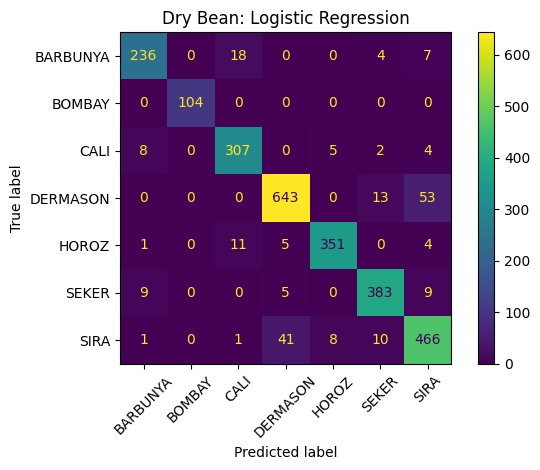

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_bean_test,
    bean_logistic_pred,
    labels=bean_labels,
    xticks_rotation=45,
)
plt.title("Dry Bean: Logistic Regression")
plt.tight_layout()
plt.show()

## Task 11. Chọn k cho KNN

Chỉ chia tập train để tạo validation. Tập test không tham gia chọn `k`.

In [ ]:
X_bean_subtrain, X_bean_val, y_bean_subtrain, y_bean_val = (
    train_test_split(
        X_bean_train,
        y_bean_train,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_bean_train,
    )
)

k_candidates = [3, 5, 7, 9, 11, 15, 21]
k_results = []

for k in k_candidates:
    candidate = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=k,
        )),
    ])

    candidate.fit(X_bean_subtrain, y_bean_subtrain)
    val_pred = candidate.predict(X_bean_val)

    k_results.append({
        "k": k,
        "Validation Accuracy": accuracy_score(
            y_bean_val,
            val_pred,
        ),
        "Validation Macro F1": f1_score(
            y_bean_val,
            val_pred,
            average="macro",
            zero_division=0,
        ),
    })

k_results_df = pd.DataFrame(k_results)
k_results_df = k_results_df.sort_values(
    ["Validation Macro F1", "Validation Accuracy"],
    ascending=False,
).reset_index(drop=True)

best_k = int(k_results_df.loc[0, "k"])

display(
    k_results_df.round({
        "Validation Accuracy": 4,
        "Validation Macro F1": 4,
    })
)

print("Best k:", best_k)

,k,Validation Accuracy,Validation Macro F1
0,21,0.9377,0.9482
1,7,0.9359,0.9473
2,15,0.9363,0.9472
3,9,0.9359,0.9471
4,5,0.9349,0.9457
5,11,0.9331,0.9443
6,3,0.9294,0.9418


Best k: 21


## Task 12. Huấn luyện và đánh giá KNN

In [ ]:
bean_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(
        n_neighbors=best_k,
    )),
])

bean_knn.fit(X_bean_train, y_bean_train)
bean_knn_pred = bean_knn.predict(X_bean_test)

bean_knn_metrics = evaluate_multiclass_model(
    f"KNN, k={best_k}",
    y_bean_test,
    bean_knn_pred,
    bean_labels,
)

,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
"KNN, k=21",0.9188,0.9328,0.9293,0.9306,0.9189


              precision    recall  f1-score   support

    BARBUNYA       0.95      0.88      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.96      0.93       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



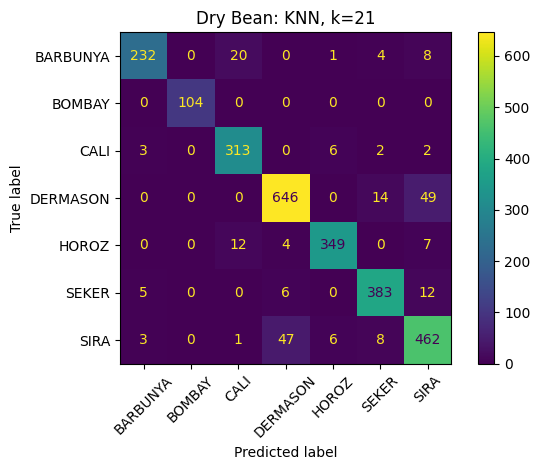

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_bean_test,
    bean_knn_pred,
    labels=bean_labels,
    xticks_rotation=45,
)
plt.title(f"Dry Bean: KNN, k={best_k}")
plt.tight_layout()
plt.show()

## Task 13. So sánh hai mô hình Dry Bean

In [ ]:
bean_comparison = pd.DataFrame({
    "Logistic Regression": bean_logistic_metrics,
    f"KNN, k={best_k}": bean_knn_metrics,
}).T

display(bean_comparison.round(4))

best_model = bean_comparison["Macro F1"].idxmax()

print("Mô hình có Macro F1 cao hơn:", best_model)
print(
    "Macro F1:",
    round(float(bean_comparison.loc[best_model, "Macro F1"]), 4),
)

,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
Logistic Regression,0.9192,0.9307,0.9300,0.9302,0.9193
"KNN, k=21",0.9188,0.9328,0.9293,0.9306,0.9189


Mô hình có Macro F1 cao hơn: KNN, k=21
Macro F1: 0.9306


In [ ]:
best_validation_row = k_results_df.iloc[0]

log_report = classification_report(
    y_bean_test,
    bean_logistic_pred,
    labels=bean_labels,
    output_dict=True,
    zero_division=0,
)

knn_report = classification_report(
    y_bean_test,
    bean_knn_pred,
    labels=bean_labels,
    output_dict=True,
    zero_division=0,
)

log_hardest_class = min(
    bean_labels,
    key=lambda label: log_report[label]["f1-score"],
)
knn_hardest_class = min(
    bean_labels,
    key=lambda label: knn_report[label]["f1-score"],
)

log_cm = confusion_matrix(
    y_bean_test,
    bean_logistic_pred,
    labels=bean_labels,
)
knn_cm = confusion_matrix(
    y_bean_test,
    bean_knn_pred,
    labels=bean_labels,
)

def largest_confusion(cm, labels):
    off_diagonal = cm.copy()
    np.fill_diagonal(off_diagonal, 0)
    row, col = np.unravel_index(
        np.argmax(off_diagonal),
        off_diagonal.shape,
    )
    return labels[row], labels[col], int(off_diagonal[row, col])

log_true, log_pred, log_count = largest_confusion(
    log_cm,
    bean_labels,
)
knn_true, knn_pred, knn_count = largest_confusion(
    knn_cm,
    bean_labels,
)

bean_comment = f"""
**Nhận xét từ kết quả validation và test:**

1. Trên validation, `k = {best_k}` đạt Macro F1 **{best_validation_row["Validation Macro F1"]:.4f}** và Accuracy **{best_validation_row["Validation Accuracy"]:.4f}**, cao nhất trong các giá trị `k` đã thử.
2. Trên test, Logistic Regression đạt Accuracy **{bean_logistic_metrics["Accuracy"]:.4f}**, nhỉnh hơn KNN **{bean_knn_metrics["Accuracy"]:.4f}**.
3. KNN đạt Macro F1 **{bean_knn_metrics["Macro F1"]:.4f}**, nhỉnh hơn Logistic Regression **{bean_logistic_metrics["Macro F1"]:.4f}**. Chênh lệch chỉ **{abs(bean_knn_metrics["Macro F1"] - bean_logistic_metrics["Macro F1"]):.4f}**, nên hiệu năng tổng thể của hai mô hình gần như tương đương.
4. Logistic Regression nhỉnh hơn về Macro Recall, **{bean_logistic_metrics["Macro Recall"]:.4f}** so với **{bean_knn_metrics["Macro Recall"]:.4f}**. KNN nhỉnh hơn về Macro Precision, **{bean_knn_metrics["Macro Precision"]:.4f}** so với **{bean_logistic_metrics["Macro Precision"]:.4f}**.
5. Lớp có F1-score thấp nhất ở Logistic Regression là **{log_hardest_class}**, F1 = **{log_report[log_hardest_class]["f1-score"]:.4f}**. Với KNN, lớp thấp nhất là **{knn_hardest_class}**, F1 = **{knn_report[knn_hardest_class]["f1-score"]:.4f}**.
6. Nhầm lẫn lớn nhất của Logistic Regression là **{log_true} → {log_pred}**, gồm **{log_count}** mẫu. Với KNN, nhầm lẫn lớn nhất là **{knn_true} → {knn_pred}**, gồm **{knn_count}** mẫu.
7. Nếu ưu tiên Accuracy và Weighted F1, Logistic Regression nhỉnh hơn. Nếu ưu tiên Macro F1 giữa bảy lớp, KNN với `k = {best_k}` nhỉnh hơn.
"""

display(Markdown(bean_comment))


**Nhận xét từ kết quả validation và test:**

1. Trên validation, `k = 21` đạt Macro F1 **0.9482** và Accuracy **0.9377**, cao nhất trong các giá trị `k` đã thử.
2. Trên test, Logistic Regression đạt Accuracy **0.9192**, nhỉnh hơn KNN **0.9188**.
3. KNN đạt Macro F1 **0.9306**, nhỉnh hơn Logistic Regression **0.9302**. Chênh lệch chỉ **0.0004**, nên hiệu năng tổng thể của hai mô hình gần như tương đương.
4. Logistic Regression nhỉnh hơn về Macro Recall, **0.9300** so với **0.9293**. KNN nhỉnh hơn về Macro Precision, **0.9328** so với **0.9307**.
5. Lớp có F1-score thấp nhất ở Logistic Regression là **SIRA**, F1 = **0.8710**. Với KNN, lớp thấp nhất là **SIRA**, F1 = **0.8660**.
6. Nhầm lẫn lớn nhất của Logistic Regression là **DERMASON → SIRA**, gồm **53** mẫu. Với KNN, nhầm lẫn lớn nhất là **DERMASON → SIRA**, gồm **49** mẫu.
7. Nếu ưu tiên Accuracy và Weighted F1, Logistic Regression nhỉnh hơn. Nếu ưu tiên Macro F1 giữa bảy lớp, KNN với `k = 21` nhỉnh hơn.


In [ ]:
titanic_best = (
    "Logistic Regression"
    if logistic_metrics["F1-score"] >= linear_metrics["F1-score"]
    else "Linear Regression"
)

bean_macro_best = (
    "Logistic Regression"
    if bean_logistic_metrics["Macro F1"] >= bean_knn_metrics["Macro F1"]
    else f"KNN với k = {best_k}"
)

conclusion = f"""
# Kết luận

- Với Titanic, **{titanic_best}** có F1-score cao hơn trên tập test. Logistic Regression cũng có Accuracy và Precision cao hơn, còn Linear Regression có Recall cao hơn.
- Với Dry Bean, **{bean_macro_best}** có Macro F1 cao hơn. Logistic Regression có Accuracy và Weighted F1 nhỉnh hơn.
- Phần Titanic giữ đúng cách chia **{len(X_train)} train, {len(X_val)} validation, {len(X_test)} test**. Bộ tiền xử lý chỉ `fit` trên tập train.
- Phần Dry Bean chọn `k` trên validation tách từ train. Tập test không tham gia chọn `k`.
- Kết quả Dry Bean của hai mô hình gần như tương đương. Mô hình phù hợp phụ thuộc chỉ số được ưu tiên.
"""

display(Markdown(conclusion))


# Kết luận

- Với Titanic, **Logistic Regression** có F1-score cao hơn trên tập test. Logistic Regression cũng có Accuracy và Precision cao hơn, còn Linear Regression có Recall cao hơn.
- Với Dry Bean, **KNN với k = 21** có Macro F1 cao hơn. Logistic Regression có Accuracy và Weighted F1 nhỉnh hơn.
- Phần Titanic giữ đúng cách chia **623 train, 134 validation, 134 test**. Bộ tiền xử lý chỉ `fit` trên tập train.
- Phần Dry Bean chọn `k` trên validation tách từ train. Tập test không tham gia chọn `k`.
- Kết quả Dry Bean của hai mô hình gần như tương đương. Mô hình phù hợp phụ thuộc chỉ số được ưu tiên.


## Bảng tự kiểm trước khi nộp

- [ ] Đã điền họ tên và MSSV.
- [ ] Notebook chạy Restart Kernel và Run All không lỗi.
- [ ] Titanic dùng đúng split 623 train, 134 validation, 134 test.
- [ ] Tiền xử lý Titanic chỉ fit trên train.
- [ ] Đã so sánh Logistic Regression và Linear Regression.
- [ ] Đã đánh giá Logistic Regression và KNN trên Dry Bean.
- [ ] Đã push notebook và các file dữ liệu cần thiết lên GitHub.